<a name="explicacion"></a>

# **Métodos espectrales**

Adptado de Mauro Fontana por Facundo Pugliese

En la Práctica 5 deberán implementar métodos espectrales para la resolución de Ecuaciones en Derivadas Parciales (EDP o PDE, por sus siglas en inglés). En los métodos espectrales la idea es obtener aproximantes globales que usen los $N$ puntos del dominio, a las funciones de interés y sus derivadas. Podemos pensar a los métodos espectrales como la proyección de la función de interés sobre un conjunto de funciones ortogonales $\{\phi_0, \phi_1, \ \dots \ , \phi_{M-1} \}$. Luego, si disponemos de la función de interés $f$ evaluada sobre nuestra grilla, es decir, $f_0, f_1, \ \dots \ , f_{N-1}$, podemos escribir el par de transformaciones
\begin{align*}
    \hat{f}_m &= \alpha^m_{MN} \sum_{n=0}^{N-1} f_n \phi_m^*(x_n), \tag{1} \\
    f_n &= \beta^n_{MN}  \sum_{m=0}^{M-1} \hat{f}_m \phi_m(x_n) \tag{2}
\end{align*}
con $\alpha^m_{MN}$ y $\beta^n_{MN}$ constantes de normalización apropiadas de forma que la composición de $(1)$ y $(2)$ resulte en la operación identidad y $^*$ denota la operación de conjugación. Los coeficientes de esta combinación lineal se obtienen sencillamente mediante la proyección sobre cada elemento de la base mediante un producto interno. Aunque hemos planteado un caso general, en esta práctica nos interesará el caso $N=M$, a modo de no "perder información" al transformar.

Aunque parezca innecesariamente complicado, podemos elegir el conjunto $\{\phi_1, \dots, \phi_m, \dots\}$ de forma que:
1. Las $\phi_m$ sean fácilmente diferenciables/integrables, por ejemplo seleccionando las mismas para que sean autofunciones de algún operador integrodiferencial o bien que sus derivadas puedan obtenerse a partir de alguna relación de recurrencia.
2. Que la transformación dada por $(1)$ y $(2)$ presente buenas propiedades de convergencia. Es decir, que alcance con pocas autofunciones $\phi_m$ e información sobre pocos puntos de grilla $x_n$ para obtener buenas aproximaciones a $f$, $f'$, etc.
3. Que las transformaciones dadas por $(1)$ y $(2)$ puedan ser estimadas de forma computacionalmente eficiente.

Es usual denominar a las cantidades $f_n$ como la representación la función en el _espacio físico_, mientras que para $\hat f_m$ se considera a la misma en el _dominio espectral_. Vale resaltar que, en general, $\hat f_m$ puede ser complejo, aún cuando $f_n$ sea real, si $\phi_m$ es una función de $\mathbb C \to \mathbb C$. Cómo vieron en la teórica, estas ideas pueden utilizarse para evolucionar directamente los $\hat f_m$ en la EDP de interés en caso que la misma dependa del tiempo, dando lugar al método de Galerkin, lo cual reduce levemente la cantidad de operaciones necesarias.

## **Método de Fourier**

### **Transformada discreta y FFT**

Dada una función con periódo $L$, cuyos valores conocemos sobre $N$ puntos, vamos a buscar representarla media una cantidad $M$ de funciones trigonométricas (y sus respectivos coeficientes), es decir

\begin{align*}
    \hat{f}_m &= \alpha^m_{MN} \sum_{n=0}^{N-1} f_n e^{- ik_m x_n}, \tag{3} \\
    f_n &= \beta^n_{MN} \sum_{m=0}^{M-1} \hat{f}_m e^{ik_m x_n} \tag{4},
\end{align*}
con $k_m = m 2\pi/L$. Esta última elección es para garantizar que todos los elementos de la base tengan período $L$.

Definidos $\alpha^m_{MN}$ y $\beta^n_{MN}$, las expresiones anteriores no son ni más ni menos que una aproximación a la serie de Fourier, y otra para los coeficientes de la misma. Adicionalmente, por motivos computacionales, vamos a considerar el caso donde los $x_n$ son equiespaciados.

Finalmente, dado que la memoria de una computadora es limitada, la cantidad de puntos de grilla $x_i$ y de números de onda $k_m$ deberá ser necesariamente finita. En particular, resulta computacionalmente atractivo el escenario en que $M = N$, ya que permite usar el uso de Transformadas Rápidas de Fourier (o _Fast Fourier Transforms_ — **FFT**— en inglés). La FFT es un algoritmo que permite calcular
\begin{align*}
    \hat{f}_m &= \sum_{n=0}^{N-1} f_n e^{- i \frac{2\pi}{N} m n}, \tag{TDF}\\
    f_n &= \frac{1}{N} \sum_{m=0}^{N-1} \hat{f}_m e^{i \frac{2\pi}{n} m n} \tag{ITDF},
\end{align*}
para todos los $\hat f_{m}$ o todos los $f_n$ en $\mathcal O (N \log(N))$ operaciones, en contraposición a las $N^2$ operaciones que surgen de computar $N$ veces la $\mathrm{TDF}$ o $(\mathrm{ITDF})$ de manera inocente. En este contexto, TDF significa Transformada Discreta de Fourier, mientras que ITDF es la transformada discreta inversa de Fourier.

Noten que la equivalencia entre las expresiones $(3)$ y $(4)$ con la TDF e ITDF surgen de las condiciones propuestas. En particular, por como definimos el grillado espacial y el espectral tenemos
\begin{equation*}
\left.\begin{aligned}
x_n = n \Delta x &= n \frac{L}{N} \\
k_m = m \Delta k &= m \frac{2\pi}{L}
\end{aligned}\right\rbrace \qquad \qquad k_m x_n = \frac{2 \pi}{N} mn.
\end{equation*}
Noten que se cancelan las dependencias sobre el espaciamiento de puntos $\Delta x$ (o el período $L$) en el cálculo.

La FFT surge de utilizar estrategias de [dividir y conquistar](https://es.wikipedia.org/wiki/Algoritmo_divide_y_vencer%C3%A1s) al problema de la TDF. Un ejemplo de la familia de técnicas de FFT es el método introducido por [Cooley y Tukey](https://www.ams.org/journals/mcom/1965-19-090/S0025-5718-1965-0178586-1/S0025-5718-1965-0178586-1.pdf) (similares a lo hallado en unas notas de Gauss públicadas póstumamente).

### **Convergencia de la FFT y fenómeno de Gibbs**

Mencionamos al inicio que de los métodos espectrales nos va a interesar fuertemente su tasa de convergencia. Dado que ya nos restringimos al estudio de funciones periódicas, sabemos que las mismas siempre pueden representarse$^\dagger$ mediante una serie de Fourier
\begin{equation*}
    f(x) = \sum_{m=-\infty}^{\infty} \hat{a}_m e^{i \frac{2\pi}{L} m x}, \qquad \qquad \hat{a}_m = \frac{1}{L} \int_{0}^{L} f(x) e^{-i \frac{2\pi}{L} m x} \mathrm d x.
\end{equation*}

Noten entonces que la ecuación $(3)$ no es ni más ni menos que una aproximación, con una regla trapezoidal, a la expresión para $\hat a_m$. No lo mostraremos, pero en general las aproximaciones $\hat f_m$ a los coeficientes $\hat a_m$ obtenidas mediante la regla tradicional, poseen un muy buen orden de convergencia. Sin embargo, lo que resta analizar es qué tan bien aproxima la serie de Fourier truncada
\begin{equation*}
    S_M(x) = \sum_{m=-M}^M \hat a_m e^{i \frac{2\pi}{L} m x}
\end{equation*}
a $f(x)$. Una respuesta rigurosa a esta pregunta excede los contenidos de la materia, sin embargo vamos a establecer y mostrar algunos resultados.

1. $|S_M(x) - f(x)|$ tiende a cero como $M^{-P}$, con $P$ la primer derivada discontinua de $f$. En caso que todas las derivadas de $f$ sean continuas, la convergencia irá como $M^{-M}$ (convergencia geométrica).
2. Si $f(x)$ tiene discontinuidades puntuales sobre el conjunto de puntos $\{x_j\}$, entonces $S_M$ converge _lentamente_ a $f(x)$ en todos lados, excepto en $\{x_j\}$ donde el error permanece constante para una cantidad finita de modos. Dicho de otra manera, para reproducir discontinuidades se precisan infinitos modos. Puede pensarse en términos de 1. como el caso con $P=0$ (es decir, ni siquiera la función es continua).
3. Una función $f$ no periódica es equivalente a una función con una discontinuidad en $x=L$. Esto surge naturalmente de considerar la extensión periódica de $f$. En términos del punto 1, esto significa que si la $p$-ésima derivada de $f$ no es periódica en $[0,L)$, entonces podemos pensar a dicha derivada como discontinua y la convergencia estará dada por $M^{-p}$.

Veamos con tres ejemplos las propiedades enunciadas. Para ello, estudiaremos numéricamente la convergencia de series de Fourier que podemos obtener analíticamente. Por simplicidad, trabajaremos en el intervalo $(-\pi, \pi)$, teniendo las funciones un periódo $2\pi$.

* La función $f(x) = \mathrm{sen}(x)/(5-3\cos(x))$ es infinitamente periódica y continua. Tiene como serie de Fourier a
\begin{equation*}
    f(x) = \sum_{m=-\infty\\ m\ne 0}^{\infty} (-i)\frac{\mathrm{sg}(m)}{3^{|m|+1}} e^{i m x},
\end{equation*}
con $\mathrm{sg}$ la función signo.

* La serie de Fourier de $f(x) = x^2$, cuya primer derivada es no periódica, está dada por
\begin{equation*}
f(x) = \frac{2\pi^2}{3} + \sum_{m=-\infty\\ m\ne 0}^{\infty} \frac{(-1)^m}{m^2} e^{i m x}.
\end{equation*}

* La [función rectangular](https://es.wikipedia.org/wiki/Funci%C3%B3n_rectangular) dada por $f(x) = \Theta(x-\pi/2) - \Theta(x+\pi/2)$, con $\Theta$ la [función de Heaviside](https://es.wikipedia.org/wiki/Funci%C3%B3n_escal%C3%B3n_de_Heaviside), que es discontinua, admite una representación de Fourier a
\begin{equation*}
f(x) = \frac{1}{2} + \sum_{m=-\infty\\ m\ne 0}^{\infty} \frac{\mathrm{sen}\left(m\frac{\pi}{2}\right)}{m \pi} e^{i m x}.
\end{equation*}
mediante los coeficientes $\hat a_m = \mathrm{sen}(m\pi/2)/(\pi m)$ para $m \gt 0$ y $\hat a_0 = 1/2$.

$\dagger$: En rigor de verdad hay algunas funciones periódicas que no admiten esta representación. Para el tipo de funciones comunes en problemas físicos estas excepciones no nos resultarán de interés.

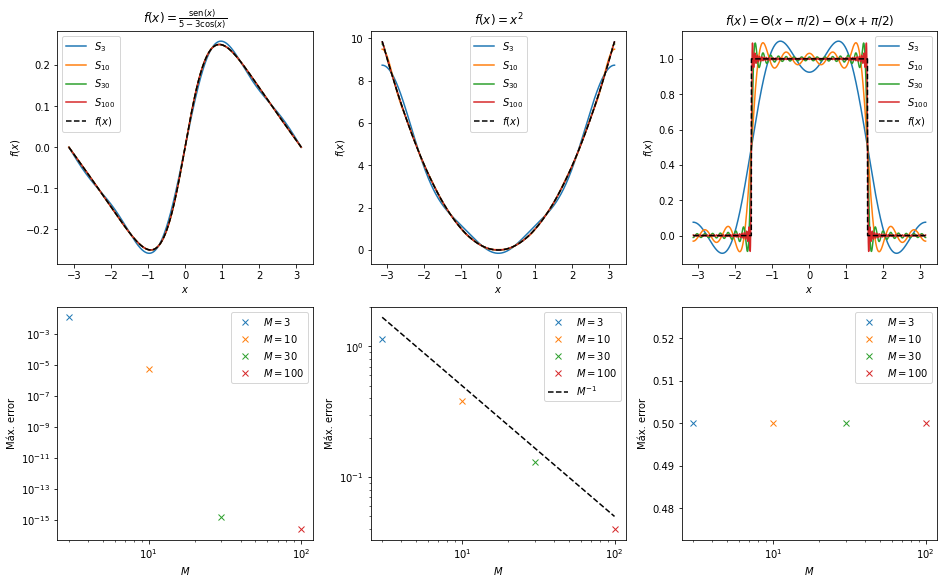

In [ ]:
#@title Cálculo de sumas parciales de Fourier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

MS = np.array([3, 10, 30, 100])

x = np.linspace(-np.pi, np.pi, 10000, endpoint=False)

def modo_trig(m):
    if m == 0:
        return 0
    else:
        return -np.sign(m)*1j/(3**(np.abs(m)+1))

f_trig = np.sin(x)/(5-3*np.cos(x))


def modo_cuad(m):
    if m == 0:
        return np.pi**2/3
    else:
        return 2*(-1)**m/m**2
f_cuad = x**2


def modo_rect(m):
    if m == 0:
        return 1/2
    else:
        return np.sin(m*np.pi/2)/(m*np.pi)

f_rect = np.zeros_like(x)
f_rect[np.abs(x) < np.pi/2] = 1
# Ajusto el valor sobre la discontinuidad para que sea 1/2
mascara_punto_medio = np.not_equal(np.roll(f_rect,-1), f_rect)
f_rect[mascara_punto_medio] = 1/2

fig, axs = plt.subplots(2,3, figsize=(13,8), constrained_layout=True)
for M in MS:
    F_trig = np.zeros_like(x, dtype=np.complex128)
    F_cuad = np.zeros_like(x, dtype=np.complex128)
    F_rect = np.zeros_like(x, dtype=np.complex128)
    for m in range(-M, M+1):
        F_trig = F_trig + modo_trig(m)*np.exp(1j*m*x)
        F_cuad = F_cuad + modo_cuad(m)*np.exp(1j*m*x)
        F_rect = F_rect + modo_rect(m)*np.exp(1j*m*x)

    F_trig = np.real(F_trig)
    error_trig = np.max(np.abs(F_trig - f_trig))
    axs[0,0].plot(x, F_trig, label=f"$S_{{{M}}}$")
    axs[1,0].loglog(M, error_trig, 'x', label=f"$M={M}$")

    F_cuad = np.real(F_cuad)
    error_cuad = np.max(np.abs(F_cuad - f_cuad))
    axs[0,1].plot(x, F_cuad, label=f"$S_{{{M}}}$")
    axs[1,1].loglog(M, error_cuad, 'x', label=f"$M={M}$")

    F_rect = np.real(F_rect)
    error_rect = np.max(np.abs(F_rect - f_rect))
    axs[0,2].plot(x, F_rect, label=f"$S_{{{M}}}$")
    axs[1,2].semilogx(M, error_rect, 'x', label=f"$M={M}$")

axs[0,0].plot(x, f_trig, "--k", label="$f(x)$")

axs[0,1].plot(x, f_cuad, "--k", label="$f(x)$")
axs[1,1].plot(MS, 5*MS**-1.0, "--k", label="$M^{-1}$")

axs[0,2].plot(x, f_rect, "--k", label="$f(x)$")

[ax.set_xlabel("$x$") for ax in axs[0,:]]
[ax.set_ylabel("$f(x)$") for ax in axs[0,:]]

[ax.set_xlabel("$M$") for ax in axs[1,:]]
[ax.set_ylabel("Máx. error") for ax in axs[1,:]]

[ax.legend() for ax in axs.flatten()]
axs[1,2].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

axs[0,0].set_title(r"$f(x)=\frac{\mathrm{sen}(x)}{5-3\cos(x)}$")
axs[0,1].set_title(r"$f(x)=x^2$")
axs[0,2].set_title(r"$f(x)=\Theta(x-\pi/2) - \Theta(x+\pi/2)$");

Si bien la convergencia (es decir que tan rápido decrecen los $\hat a_m$) puede verse directamente de las expresiones, vemos que efectivamente la tasa de convergencia en cada caso obedece las reglas generales que establecimos arriba.

Para la primera función, vemos una convergencia extremadamente rápida, al punto que para solo $30$ modos ya nos encontramos con las limitaciones de la aritmética de punto flotante. Por otro lado, para el caso de la segunda función, que presenta una derivada no periódica, vemos que la convergencia es de primer orden. Finalmente, para el caso discontinuo vemos una convergencia lenta lejos de los puntos de discontinuidad, mientras que en un entorno de los mismos no hay convergencia, como muestra el error constante. Adicionalmente, vemos para este caso la presencia de oscilaciones alrededor de la discontinuidad. Esto es conocido como [_fenómeno de Gibbs_](https://es.wikipedia.org/wiki/Fen%C3%B3meno_de_Gibbs) o _ringing_. Este tipo de oscilaciones pueden resultarnos de interés porque cuando las encontramos en una solución numérica pueden estar indicando que la solución buscada es discontinua, o bien que precisamos una mayor resolución a efectos de resolver un gradiente de gran magnitud.

Un detalle interesante que podemos ver gráficamente, es que en presencia del fenómeno de Gibbs el salto alrededor de la discontinuidad que obtenemos por utilizar una cantidad finita de modos es $\approx 18\%$ mayor que el que presenta la función real, independientemente de la cantidad de modos utilizados. Noten que todas las curvas coloreadas en la tercer columna presentan escencialmente la misma amplitud cerca de la discontinuidad.

### **Cálculo de derivadas y productos con FFT**

Luego de establecer qué tipo de funciones vamos a poder representar y qué tan bien funcionarán dichas aproximaciones en la práctica, podemos concentrarnos en nuestro principal interés para el uso de expansiones trigonométricas: el cálculo de derivadas.

Esto va a resultar muy sencillo puesto que las funciones de tipo $e^{ikx}$ son autofunciones del operador de derivación. En otras palabras
\begin{equation*}
    \frac{\mathrm d }{\mathrm d x} e^{ikx} = (ik) e^{ikx}.
\end{equation*}
Luego, en caso que nuestra suma de Fourier presente buenas propiedades de convergencia, tendremos que
\begin{align*}
    f'(x) = \frac{\mathrm d}{\mathrm d x} \left[ f(x) \right] & \approx \frac{\mathrm d}{\mathrm d x} \left[ \sum_{m=-M}^{M} \hat f_m e^{ik_m x} \right] \\
    &= \sum_{m=-M}^{M} (ik_m \hat f_m) e^{ik_m x} = \sum_{m=-M}^{M} \hat f'_m e^{ik_m x}.
\end{align*}
Es decir, tenemos una serie de Fourier para $f'$, cuyos coeficientes pueden obtenerse a partir de aquellos para $f$ sencillamente como $\hat f'_m = ik_m \hat f_m$. Derivadas de orden $q$ reducen a $\hat f^{(q)}_m = (ik_m)^q \hat f_m$. En espacio espectral, esto es todo: las derivadas se vuelven productos.

Los productos, sin embargo, son más complicados. Si tenemos dos funciones $f(x)$ y $g(x)$ con sus respectivos coeficientes de fourier $\hat f_m$ y $\hat g_m$, su producto tendrá serie de Fourier con coeficientes $\widehat{(fg)}_m$
\begin{align*}
(fg)(x) &\approx \left[ \sum_{n=-M}^{M} \hat{f}_n e^{ik_n x} \right]\left[ \sum_{\ell=-M}^{M} \hat{g}_\ell e^{ik_\ell x} \right] \\
\left[ \sum_{m=-M}^{M} \widehat{(fg)}_m e^{ik_m x} \right]  &\approx \sum_{m=-2M}^{2M}\left[\sum_{n=-M}^{M} \hat f_n \hat g_{m+n} \right]e^{ik_m x}
\end{align*}
donde usamos que $k_m = k_\ell + k_n$ si y solo si $m = \ell + n$ para reescribir la última suma agrupando por números de onda $k_m$.
A su vez, $m$ se moverá entre $-2M$ y $M$, lo cual se escapa de nuestra representación, por lo que ignoraremos esos coeficientes.
Comparando ambos extremos, notamos que los $\widehat{(fg)}_m$ serán una convolución de los $\hat{f}_m$ y $\hat{g}_m$, lo cual en principio requiere $O(M^2)$ operaciones. Para evitar esto, haremos nuevamente uso de la FFT para reducir este costo a $O(M\log M)$.

La forma práctica de usar esto para calcular productos a partir de dos conjuntos de valores $\hat{\mathbf{f}} = (\hat f_{-M}, \hat f_{-M+1}, \ \dots \, \hat f_{M-1} , \hat f_{M})$ y $\hat{\mathbf{g}} = (\hat g_{-M}, \hat g_{-M+1}, \ \dots \, \hat g_{M-1} , \hat g_{M})$ en el dominio espectral pasando por el dominio real es la siguiente:
1. Se calcula la IFFT de $\hat{\mathbf{f}}$, obteniendo los conjuntos de coeficientes $\mathbf f = (f_0, f_1, \ \dots \ , f_{N-1})$ y $\mathbf g = (g_0, g_1, \ \dots \ , g_{N-1})$.
2. Se realiza el producto elemento a elemento, obteniendo un tercer conjunto de coeficientes $\mathbf h = (f_0g_0, f_1g_1, \ \dots \ , f_{N-1}g_{N-1})$ en dominio real.
3. Se aplica la FFT para obtener $\hat{\mathbf{h}}$ correspondiente a los coefientes $\widehat{(fg)}_m$. Nótese que esto eliminará los coeficientes "extra" que mencionamos en el párrafo anterior automáticamente.

<b> Sobre los números de onda </b>

Si bien es posible considerar a los números de onda enteramente positivos, de forma de que discreticen el dominio angular $[0, 2\pi/ \Delta x)$ es más común, tanto para la presentación de resultados como para los cálculos, considerar números de onda definidos en $[-\pi/\Delta x, \pi/\Delta x)$. Sin bien esta última forma resulta más simétrica (además que permite visualizar más rápidamente qué modos están correctamente resueltos), deben tener en cuenta que en caso que $N$ sea par se tendrán $N/2$ números de onda negativos y $N/2 -1$ números de onda positivos. Para el caso de $N$ impar se tienen la misma cantidad de modos negativos y positivos.

### **FFT en Python**

<font size="small">
(Esta subsección está adaptada de aquella presentada oportunamente en la Práctica 3)

Resulta extremadamente sencillo calcular la FFT de una cierta señal en Python. Existen numerosos paquetes que realizan esta tarea, sin embargo nos concentraremos en la interfaz brindada por [`numpy.fft`](https://numpy.org/doc/stable/reference/routines.fft.html).

Para esto podemos usar la función [`numpy.fft.fft`](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft) que calcula la descomposición de Fourier en una dimensión de un arreglo. En caso que dicho arreglo posea más de una dimensión, podemos seleccionar sobre cuál queremos realizar la transformada mediante el argumento `axis`. Por ejemplo, dado un arreglo `f[i,j]` donde el índice `i` corresponde a distintos tiempos y `j` a distintas posiciones en el espacio, podemos calcular la transformada de Fourier en espacio como `numpy.fft.fft(f, axis=1)`.

Como notarán, y conforme a lo que mencionamos anteriormente, no es necesario contar con información sobre el espaciamiento entre puntos para calcular la FFT, basta con que sean equiespaciados. Sin embargo, está información sí resulta necesaria para interpretar los valores $\hat{f}_m$ como el contenido espectral asociado al número de onda $k_m$. Numpy nos ofrece la función [`numpy.fft.fftfreq`](https://numpy.org/doc/stable/reference/generated/numpy.fft.fftfreq.html) (donde freq denota frecuencia, el equivalente temporal al número de onda). Por ejemplo, si la señal original (en el espacio $x$) tenía `N` puntos y un espaciamiento `dx`, podemos obtener el vector $\mathbf k$ como `2*numpy.pi*numpy.fft.fftfreq(N, d=dx)`. El factor de $2\pi$ interviene para expresar a los números de onda en unidades de $\text{rad}/\text{m}$ en lugar de $1/\text{m}$.

Dado un arreglo de $N$ cantidades (reales o complejas), `numpy.fft.fft` devuelve un arreglo de $N$ **cantidades complejas**. Adicionalmente, adopta la convención de que devuelve primero el espectro correspondiente al número de onda $k_m=0$, seguido de los elementos asociados a $k_m>0$ y finalmente aquellos asociados a $k_m < 0$. Este ordenamiento, por consistencia, es también seguido por `numpy.ffy.fftfreq`.

Veamos un código que calcula el espectro de amplitud $|\hat f(k_m)|$ y de fase $\theta_m = \arctan[\mathrm{Im}\{\hat f(k_m)\}/\mathrm{Re}\{\hat f(k_m)\}]$ de la función $f(x) = \mathrm{sen}(x) + \mathrm{sen}(9x)$, que es $2\pi$-periódica. Esperamos que la amplitud presente picos para $|k|=1$ y $|k|=9$. Veamos que efectivamente es así:

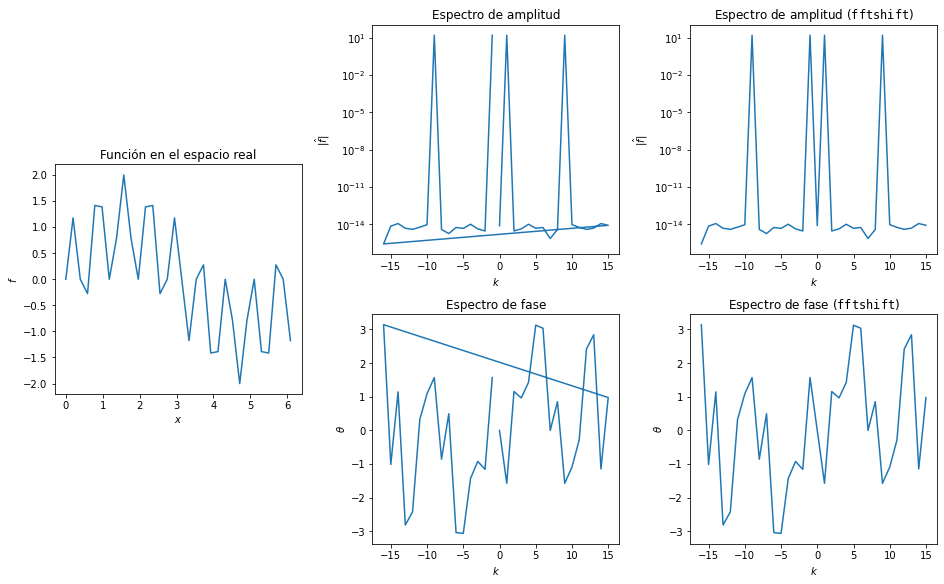

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

N = 32                                                      # Número de puntos
L = 2*np.pi                                                 # Tamaño del dominio
x, dx = np.linspace(0, L, N, endpoint=False, retstep=True)  # Grilla espacial
f = np.sin(x) + np.sin(9*x)                                 # Función objetivo

k = 2*np.pi*np.fft.fftfreq(N, d=dx)       # Grilla espectral
F = np.fft.fft(f)                         # Transformada de Fourier

amp = np.abs(F)                           # Amplitud
fas = np.arctan2(np.imag(F), np.real(F))  # Fase

# Figura (con un par de ejes abarcando dos filas)
fig = plt.figure(figsize=(13,8), constrained_layout=True)
gs  = gridspec.GridSpec(4, 3, figure=fig)
ax0 = plt.subplot(gs[1:3, 0])
ax1 = plt.subplot(gs[ :2, 1])
ax2 = plt.subplot(gs[ :2, 2])
ax3 = plt.subplot(gs[2: , 1])
ax4 = plt.subplot(gs[2: , 2])

ax0.plot(x, f)
ax0.set_title("Función en el espacio real")
ax0.set_xlabel("$x$")
ax0.set_ylabel("$f$")

ax1.semilogy(k, amp)
ax1.set_title("Espectro de amplitud")
ax1.set_xlabel("$k$")
ax1.set_ylabel("$|\hat f|$")

ax2.semilogy(np.fft.fftshift(k), np.fft.fftshift(amp))
ax2.set_title("Espectro de amplitud ($\mathtt{fftshift}$)")
ax2.set_xlabel("$k$")
ax2.set_ylabel("$|\hat f|$")

ax3.plot(k, fas)
ax3.set_title("Espectro de fase")
ax3.set_xlabel("$k$")
ax3.set_ylabel(r"$\theta$")

ax4.plot(np.fft.fftshift(k), np.fft.fftshift(fas))
ax4.set_title("Espectro de fase ($\mathtt{fftshift}$)")
ax4.set_xlabel("$k$")
ax4.set_ylabel(r"$\theta$");

Noten que en la columna del medio los gráficos presentan una discontinuidad cerca del 0 y una línea un tanto extraña que conecta los valores en los extremos de los intervalos. Esto se debe a que, como mencionabamos antes, Numpy organiza las cantidades de manera que primero aparecen los números de onda positivos y luego los negativos, generando estas discontinuidades al graficar. Para subsanar esto, podemos utilizar la función `numpy.fft.fftshift` que reacomoda los valores para que aparezcan primero aquellos asociados a $k < 0$ y luego aquellos con $k > 0$, quedando $k=0$ en el medio. Esta operación debemos realizarla tanto para el vector `k` como para el vector `F` (o para cualquier cantidad derivada del mismo), de manera que su orden siga siendo consistente.

Reparen además en que $|f(k_m)|$ es simétrico con respecto al origen, mientras que $\theta_m$ es antisimétrico. Esto obedece a una simetría presente en $\hat f$ cuando $f$ es real. Existen funciones que aprovechan esta simetría para disminuir el costo de cómputo y de almacenamiento de las FFTs de funciones reales. Estas funcionalidades pueden accederse mediante las interfaces [`numpy.fft.rfft`](https://numpy.org/doc/stable/reference/generated/numpy.fft.rfft.html#numpy.fft.rfft) y [`numpy.fft.rfftfreq`](https://numpy.org/doc/stable/reference/generated/numpy.fft.rfftfreq.html#numpy.fft.rfftfreq). Sin embargo, dado que los ahorros que proporcionan no serán determinantes para la realización de esta práctica, no será necesario que las empleen. Más aún, cuando trabajemos con funciones complejas, estos métodos nos resultarán inútiles.

Para realizar la transformación inversa, Numpy prove [`numpy.fft.ifft`](https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html), que se usa de la misma manera que la transformada directa. Noten, sin embargo, que `ifft` devuelve un arreglo de números complejos, por lo que si quieren la parte real del mismo, deben utilizar [`numpy.real()`](https://numpy.org/doc/stable/reference/generated/numpy.real.html). Veamos un ejemplo:

In [ ]:
import numpy as np

f  = np.arange(0,15)**2
F  = np.fft. fft(f)
fb = np.fft.ifft(F)

print("Tipo de arreglo después de la IFFT:", fb.dtype)
print("Igualdad entre las partes reales antes y después de transformar:",
      np.all(np.isclose(f, np.real(fb))))

Tipo de arreglo después de la IFFT: complex128
Igualdad entre las partes reales antes y después de transformar: True


### **Solapamiento (_aliasing_)**

Un tópico que no mencionamos hasta el momento es aquel relacionado con la resolución necesaria para poder reproducir fidedignamente una función mediante una serie de Fourier truncada, i.e. mediante una transformada discreta de Fourier.

En cierta manera ya hemos respondido implícitamente a este interrogante. Afirmamos más arriba que los números de onda que podemos resolver con nuestra grilla espectral están dados por $k \in (-\pi/\Delta x, \pi/\Delta x)$. Si pensamos en términos de longitudes de onda, la longitud de onda más corta que podemos resolver $\lambda$ está dada por
\begin{equation*}
\lambda_{\text{min}} = \frac{2\pi}{\max(|k|)} = 2\Delta x.
\end{equation*}
Dicho de otra manera, para poder representar adecuadamente una onda $\mathrm{sen}(x/(2\pi\lambda))$, precisamos contar más de 2 muestras por longitud de onda. Este resultado es conocido como [Teorema de muestreo](https://es.wikipedia.org/wiki/Teorema_de_muestreo_de_Nyquist-Shannon)$^\dagger$.

Veamos computacionalmente que sucede si no cumplimos con este requisito:

<font size="small">
$^\dagger$: Este problema fue estudiado por Claude Shannon, quien mostró matemáticamente resultados experimentales de telegrafía comunicados previamente por Harry Nyquist. Por ese motivo a veces se nombra a este teorema como <i>Teorema de muestreo de Nyquist-Shannon</i>.

In [ ]:
#@title Verificación computacional del aliasing
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Layout
from IPython.display import display

lamda = 1/8

x, dx = np.linspace(0, 1, 10000, endpoint=False, retstep=True)

f = np.sin(2*np.pi*x/lamda) + 1
F = np.fft.fftshift(np.abs(np.fft.fft(f)))**2/10000**2
k = np.fft.fftshift(2*np.pi*np.fft.fftfreq(x.size, dx))

def anim(ppw):
    dxm = lamda/ppw
    nxm = int(round(1/dxm))

    xm = np.arange(0, nxm+1)*dxm
    fm = np.sin(xm*2*np.pi/lamda) + 1
    FM = np.fft.fftshift(np.abs(np.fft.fft(fm)))**2/nxm**2
    km = np.fft.fftshift(2*np.pi*np.fft.fftfreq(xm.size, dxm))

    fig, axs = plt.subplots(2, 1, figsize=(10,5), constrained_layout=True)
    fig.suptitle(rf"$\lambda = {lamda/dxm:.3f} \Delta x$")
    axs[0].plot(x , f , 'k')
    axs[0].plot(xm, fm, '-x', c="C1")
    axs[0].set_xlabel("$x$")
    axs[0].set_ylabel("$f$")

    axs[1].plot(k , F , 'ok')
    axs[1].plot(km, FM, 'o', c="C1")
    axs[1].set_xlim(-3*np.pi/lamda, 3*np.pi/lamda)
    axs[1].set_xlabel("$k$")
    axs[1].set_ylabel(r"$|\hat f|^2$")

    plt.show()

slider = FloatSlider(
    value=4,
    min=1,
    max=4,
    step=0.1,
    description="Puntos por longitud de onda",
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=Layout(width='auto'),
    style= {'description_width': 'initial'}
)

interact(anim, ppw=slider);

interactive(children=(FloatSlider(value=4.0, description='Puntos por longitud de onda', layout=Layout(width='a…

La figura interactiva permite muestrear una función, en este caso un seno con una cierta longitud de onda, con una cantidad variable de puntos por muestra. El panel superior muestra el efecto del muestreo, mientras que el inferior muestra el espectro de potencias (i.e. la magnitud de los $\hat f (k_m)$).

Vemos que si muestreamos nuestra función con más de dos puntos por longitud de onda, el espectro queda correctamente resuelto. En el espacio físico también vemos que una estimación del período de la función naranja coincide con la de la función real (en negro). Sin embargo, cuando empezamos a tener menos de dos muestras por longitud de onda, el período de la curva naranja empieza a ser distinto que el de la curva negra. En el espacio de Fourier, esto lo vemos con picos en el espectro de potencias que en lugar de estar en $k = 50$, aparecen para valores menores de $k$. En particular, cuando tenemos 3 muestras cada dos longitudes de onda $\Delta x = 3 \lambda/2$, vemos una duplicación del período.

Sin embargo, esto es un problema, ya que si no conocemos $f$, un mal muestreo puede resultar en que veamos energía en escalas que nuestro problema no tiene. Más aún, esta energia _espuria_ se vuelve indistinguible de la energía que realmente corresponde a dicho modo. Veamos un ejemplo para la función $f(x) = \mathrm{sen}(2x) + \mathrm{sen}(32x)$, con un muestreo que no alcanza a resolver el modo asociado al segundo término:

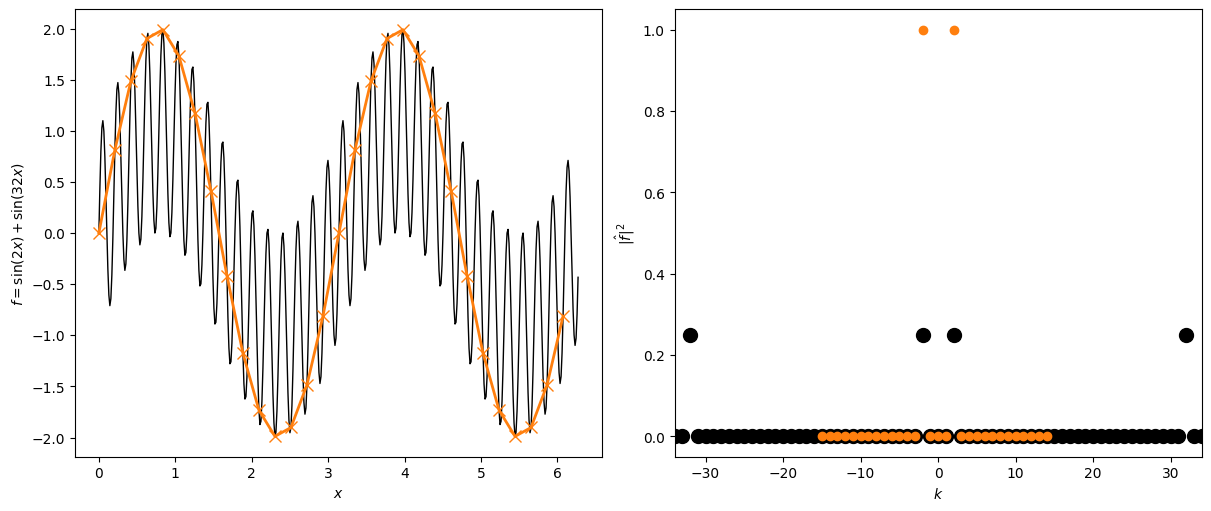

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

NX = 30
k  = 2

SS = 16

x1, dx1 = np.linspace(0, 2*np.pi,    NX, endpoint=False, retstep=True)
x2, dx2 = np.linspace(0, 2*np.pi, SS*NX, endpoint=False, retstep=True)

f1 = np.sin(k*x1) + np.sin(16*k*x1)
f2 = np.sin(k*x2) + np.sin(16*k*x2)

F1 = np.fft.fftshift(np.abs(np.fft.fft(f1)))**2/NX**2
F2 = np.fft.fftshift(np.abs(np.fft.fft(f2)))**2/(SS*NX)**2

k1 = np.fft.fftshift(2*np.pi*np.fft.fftfreq(x1.size, dx1))
k2 = np.fft.fftshift(2*np.pi*np.fft.fftfreq(x2.size, dx2))

fig, axs = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
axs[0].plot(x2, f2, 'k', lw=1)
axs[0].plot(x1, f1, '-x', c="C1", lw=2, ms=8)
axs[0].set_xlabel("$x$")
axs[0].set_ylabel(rf"$f = \mathrm{{sin}}({k}x) + \mathrm{{sin}}({16*k}x)$")

axs[1].plot(k2, F2, 'ok', markersize=10)
axs[1].plot(k1, F1, 'o', c="C1")
axs[1].set_xlim(-17*k, 17*k)
axs[1].set_xlabel("$k$")
axs[1].set_ylabel(r"$|\hat f|^2$");


Si solo tuvieramos la información en naranja, concluiriamos que hay mucha más energía sociada al modo $k=2$ de la que nuestra señal realmente tiene. Esto es debido a que, por el fenómeno de _aliasing_, se nos está mezclando la energía correspondiente a $k=2$ con aquella para $k=32$.

#### **Aliasing no-lineal**

De la discusión previsa surge que para resolver numéricamente un problema con un método de Fourier$^\dagger$ debemos contar con una grilla que provea más de dos puntos de grilla por longitud característica del problema. En caso que existan varias longitudes características, debemos representar correctamente la menor de ellas. Para problemas lineales esto implica sencillamente que debemos elegir un valor de $N$ apropiado para nuestra grilla.

Sin embargo, los problemas no-lineales dependientes del tiempo introducen una dificultad adicional, y es que en cada paso se introducen armónicos de orden superior cómo discutimos previamente para productos. Para ver fácilmente esto basta considerar $\mathrm{sen}^2(x) = (1 - \cos(2x))/2$. La consecuencia de esto es que, si la integración temporal es suficientemente larga, no importa la resolución que usemos siempre vamos a terminar con energía de armónicos superiores, que no resolvemos correctamente, mezclada en nuestra grilla, por efecto del _aliasing_.

La estrategia para que, dado un cierto número de onda máximo $k_\text{máx}$ (o lo que es lo mismo, una cierta resolución espacial $N$) podamos asegurar que la energía presente en nuestra solución corresponde realmente a los armónicos $(-k_\text{máx}, k_\text{máx})$ es utilizar un filtro. Lo más sencillo es realizar los cálculos con una resolución mayor a la que nos interesa, $N'$, que dará lugar a un correspondiente $k'_\text{máx}$. Luego, si elegimos correctamente $k'_\text{máx}$ para que los términos no-lineales queden correctamente resueltos (i.e. no tengan _aliasing_), basta con eliminar todos los modos tales que $|k_\text{máx}| < k < |k_\text{máx}|$.

Si bien la solución mencionada requiere un mayor costo computacional (terminamos con grillas espaciales más finas de lo que efectivamente resolvemos), nos permite resolver el solucionar del aliasing de manera **exacta**. Existen otras técnicas que buscan minimizar la amplitud del _aliasing_ no-lineal por debajo de un cierto umbral prefijado, no veremos técnicas de este tipo.

**Para no-linealidades cuadráticas** (como la que aparece en la ecuación de Navier-Stokes incompresible), basta con escoger
\begin{equation*}
    k'_\text{máx} = \frac{3}{2} k_\text{máx},
\end{equation*}
esquema conocido como [**_regla de los tres medios_**](https://journals.ametsoc.org/view/journals/atsc/28/6/1520-0469_1971_028_1074_oteoai_2_0_co_2.xml). A este filtrado se lo denomina también **_regla de los dos tercios_**. El origen de este segundo nombre surge de pensar la misma situación pero al revés, se tiene una grilla de $N$ puntos con un cierto $k_\text{máx}$, para evitar el aliasing debo anular los modos para todos los $k$ tales que
\begin{equation*}
    |k| > \frac{2}{3} k_\text{máx},
\end{equation*}
y por lo tanto las escalas que voy a resolver en mi simulación son aquellas menores a $2 k_\text{máx}/3$.

La forma de hacer esto computacionalmente es utilizar el cuadrado de los  números de onda normalizados
\begin{equation*}
    \tilde{k}_m^2 = \frac{k_m^2}{\max(k_m^2)}.
\end{equation*}
Luego basta con imponer
\begin{equation*}
    \hat{f}_m = 0 \qquad \qquad \forall \ m: \tilde{k}^2_m > \frac{4}{9}.
\end{equation*}

Esta tarea puede realizarse fácilmente en Python mediante el uso de máscaras. Por ejemplo, mediante el código
```python
    kn = k**2 / np.max(np.abs(k))**2
    F[kn > 4/9] = 0
```
donde `k` es un vector que contiene a los números de onda y `F` uno complejo que contiene a una serie de coeficientes $\hat{f}_m$.

No linealidades de orden $\ell \geq 2$ disponen de reglas análogas de la forma "dos $(\ell+1)$-avos", tales que
basta con imponer
\begin{equation*}
    \hat{f}_m = 0 \qquad \qquad \forall \ m: \tilde{k}^2_m > \left(\frac{2}{\ell+1}\right)^2.
\end{equation*}

##**Ejemplo: Ecuación de Burguers**
Apliquemos todo esto ahora para la ecuación de Burguers en un dominio periódico de longitud $L$ y viscosidad $\nu$
$$ \frac{\partial u}{\partial t} +  u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$
o, equivalentemente,
$$ \frac{\partial u}{\partial t} =  \nu \frac{\partial^2 u}{\partial x^2} - \frac{\partial}{\partial x}\left(\frac{u^2}{2}\right)$$

###**El código**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Nx = 256       # Tamaño de la grilla (espacial)
Nt = 3000      # Número de pasos temporales
dt = 5e-4      # Paso temporal
nu = 5e-3      # Viscosidad
L  = 1.0       # Tamaño del dominio (adimensionalizado)

# Modos Fourier precalculados para usar cada vez
kx = 2*np.pi*np.fft.fftfreq(Nx, d=L/Nx)   # Paso a "frecuencia angular"
k2 = kx**2
k2max = k2.max()*4/9

def dealias(f_fft):
  """
  Aplica la regla de los dos tercios para eliminar el aliasing no-lineal.

  Args:
    f_fft (numpy.ndarray): Arreglo de coeficientes de Fourier de una función.

  Returns:
    numpy.ndarray: Arreglo de coeficientes de Fourier con los modos de aliasing anulados.
  """
  df_fft = f_fft
  df_fft[k2 > k2max] = 0
  return df_fft

def du_dt(u_fft):
  """
  Calcula la derivada temporal de u (du/dt) en el espacio de Fourier para la ecuación de Burgers.

  Args:
    u_fft (numpy.ndarray): Arreglo de coeficientes de Fourier de la función u(x, t).

  Returns:
    numpy.ndarray: Arreglo de coeficientes de Fourier de du/dt.
  """
  u_real = np.real(np.fft.ifft(u_fft))         # Paso a espacio real
  u2_fft = dealias(np.fft.fft(u_real*u_real))  # Hago producto y dealiasing
  grad_u2_fft = 1j*kx*u2_fft                   # Tomo derivada primera
  lap_u_fft = -k2*u_fft                        # Tomo derivada segunda
  return nu*lap_u_fft - 0.5*grad_u2_fft

def paso_RK2(X, dX_dt, dt):
  """
  Realiza un paso de integración temporal utilizando el método Runge-Kutta de orden 2 (Heun).
  Asume ausencia de dependencia temporal explícita.

  Args:
    X (numpy.ndarray): Estado actual del sistema (coeficientes de Fourier).
    dX_dt (function): Función que calcula la derivada temporal del estado (du/dt).
    dt (float): Paso de tiempo.

  Returns:
    numpy.ndarray: Nuevo estado del sistema después de un paso de tiempo.
  """
  k1 = dX_dt(X)
  k2 = dX_dt(X+k1*dt)
  return X + 0.5*dt*(k1+k2)

def evolucionar(u0, Nt, dt):
  """
  Evoluciona la ecuación de Burgers en el tiempo utilizando el método espectral.

  Args:
    u0 (numpy.ndarray): Condición inicial de la función u(x) en el espacio real.
    Nt (int): Número total de pasos de tiempo.
    dt (float): Paso de tiempo para la integración.

  Returns:
    numpy.ndarray: Solución u(x, t) en el espacio real para todos los pasos de tiempo.
  """
  u = np.zeros((Nt+1, Nx),              # Arreglo con mi solución u(t, x)
               dtype=np.complex128)
  u[0] = np.fft.fft(u0)                 # Condición inicial
  for n in range(Nt):                   # Hago un paso de RK2 para cada tiempo
    u[n+1] = paso_RK2(u[n], du_dt, dt)
  return np.fft.ifft(u, axis=-1).real   # Antitransformo Fourier en el espacio

1.5 3000


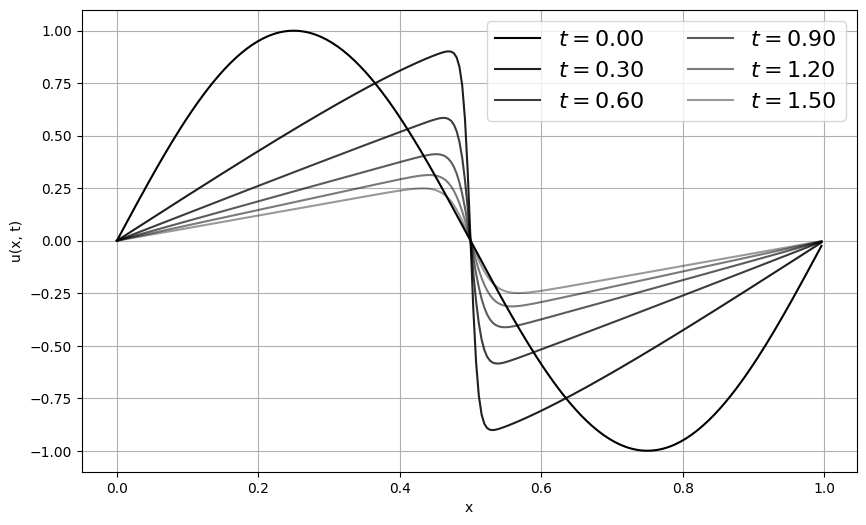

In [ ]:
x = np.linspace(0, L, Nx, endpoint=False) # Defino la grilla espacial
u0 = np.sin(2*np.pi*x)                    # Condicion inicial sinusoidal
# Evolvuciono la ecuacion de Burgers
u = evolucionar(u0, Nt, dt)
tiempos = np.arange(0, Nt+1)*dt

# Grafico algunos estados entre el inicial y el final
Ng = 5   # Cantidad de tiempos total (menos 1)
idxs = np.arange(0, Nt+2, Nt//Ng)
print(tiempos[idxs[-1]], idxs[-1])
alphas = np.linspace(0.4, 1, Ng+1)[::-1]
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for i, idx in enumerate(idxs):
  ax.plot(x, u[idx, :], "k-", alpha=alphas[i], label=r"$t=%.2f$" %tiempos[idx])
ax.grid()
ax.legend(fontsize=16, loc="upper right", ncol=2)
ax.set_xlabel("x")
ax.set_ylabel("u(x, t)")
plt.show()

### Gráficos espacio-temporales

Aunque graficar para distintos tiempos es lo más intuitivo, sería más práctico tener una visualización simultánea de tanto tiempo cómo espacio. Esto lo logramos con la función `imshow` para visualizar un mapa de color, cómo muestra el código a continuación.
El tiempo corresponde al eje horizontal, la posición al eje vertical y el color al valor de $u(x, t)$.
Cada uno de los gráficos anteriores sería un corte vertical del mapa de color. Si queremos ver la dinámica de un dado punto de grilla $x$ en el tiempo, hacemos un corte horizontal.
Podemos ver cómo los extremos del seno convergen sobre el centro del dominio, generando un gradiente extremo, que graficamos también usando la función `derivada` provista al final.

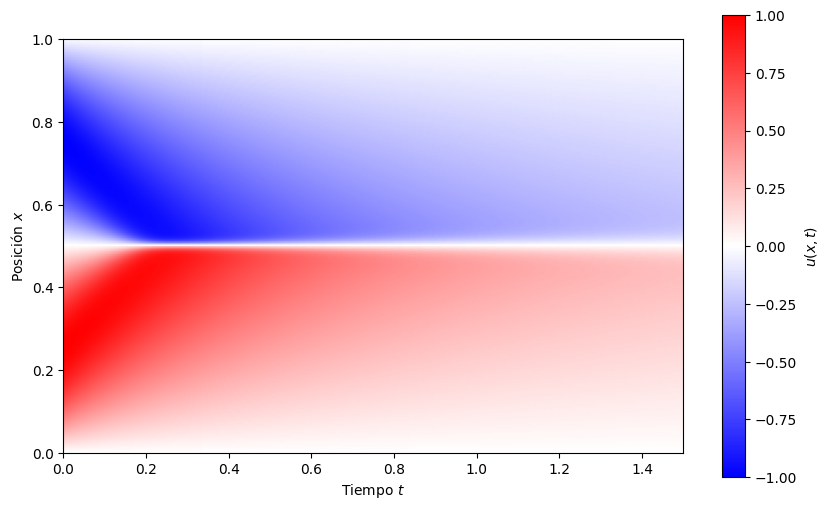

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
im = ax.imshow(u.T, origin="lower", extent=[0,tiempos[-1], 0, L], cmap="bwr")
cbar = fig.colorbar(im)
ax.set_xlabel("Tiempo $t$")
ax.set_ylabel("Posición $x$")
cbar.set_label("$u(x,t)$")

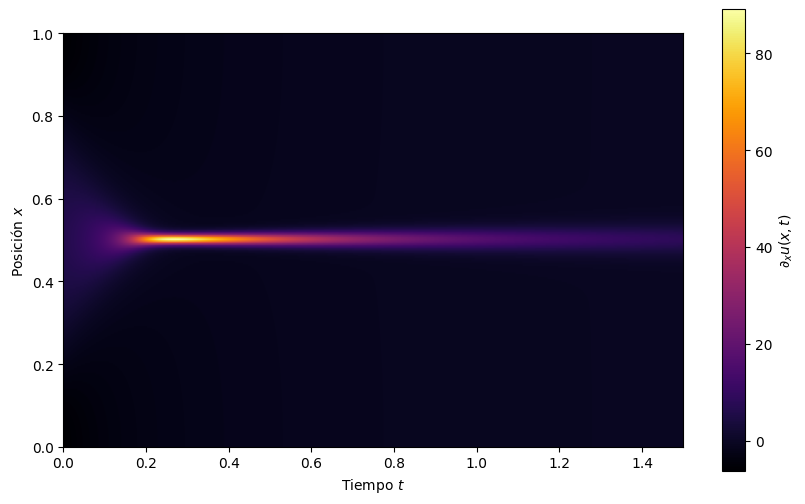

In [ ]:
def derivada(f):
  Nx = f.shape[-1]
  kx = 2j*np.pi*np.fft.fftfreq(Nx, d=L/Nx)
  f_fft = np.fft.fft(f, axis=-1)
  return np.fft.ifft(kx*f_fft, axis=-1).real

du_dx = derivada(u)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
im = ax.imshow(-du_dx.T, origin="lower", extent=[0,tiempos[-1], 0, L], cmap="inferno")
cbar = fig.colorbar(im)
ax.set_xlabel("Tiempo $t$")
ax.set_ylabel("Posición $x$")
cbar.set_label(r"$\partial_x u(x,t)$")